In [197]:
import pandas

# Read the Grammies

This is the main grammies dataset. It contains all the data for the Grammies, including the nominees and winners for each category, as well as the artists and songs that were nominated. __Copy paste the newer values in the grammies.json file which will then clean and create grammies_v4.json file with the clean data.__

In [198]:
df = pandas.read_json('json/grammies.json')

In [199]:
df = df[['annual_edition', 'year', 'award', 'artist', 'artist_link', 'producers', 'song_or_album', 'url', 'winner']]

In [200]:
df.shape

(25535, 9)

In [201]:
df = df.astype({'year': 'Int64', 'annual_edition': 'Int64', 'winner': 'bool'})

The latest iterations of the page do not include the year but include the edition as starting number for the title

In [202]:
def set_year(value: int):
    if value == 66:
        return 2023
    
    if value == 65:
        return 2022
    
    if value == 64:
        return 2021

    if value == 67:
        return 2024

    if value == 68:
        return 2026

    return value

In [203]:
df['year'] = df.year.map(set_year)

In [204]:
df.sort_values(by=['year', 'award'], inplace=True)

## Data cleaning

Remove certain values from the producers column in particular ("\r and \n") and replace them with a comma. This is because the producers column is a list of producers, and the values are separated by a comma.

In [205]:
def remove_newlines(value: str):
    if value is None:
        return value
    
    try:
        return value.replace('\r', '').replace('\n', ' ')
    except:
        return value

In [206]:
df.producers = df.producers.map(remove_newlines)

In [207]:
def clean_artist(value: str | None):
    if value is None:
        return value

    if isinstance(value, float):
        return value

    if ', artist' in value:
        value = value.replace(', artist', ' > artist')

    if ', conductor' in value:
        value = value.replace(', conductor', ' > conductor')

    if ', songwriter' in value:
        value = value.replace(', songwriter', ' > songwriter')

    if ', pianist' in value:
        value = value.replace(', pianist', ' > pianist')

    if ', composer' in value:
        value = value.replace(', composer', ' > composer')

    if ', arranger' in value:
        value = value.replace(', arranger', ' > arranger')

    if ', engineer/mixer' in value:
        value = value.replace(', engineer/mixer', ' > engineer/mixer')

    if ', producer' in value:
        value = value.replace(', producer', ' > producer')

    if ', composer & lyricist' in value:
        value = value.replace(', composer & lyricist',
                              ' > composer & lyricist')

    if ', lyricist' in value:
        value = value.replace(', lyricist', ' > lyricist')

    if ', principal vocalists' in value:
        value = value.replace(', principal vocalists',
                              ' > principal vocalists')

    if ', art directors' in value:
        value = value.replace(', art directors', ' > art directors')

    if ', album notes writers' in value:
        value = value.replace(', album notes writers',
                              ' > album notes writers')

    if ', engineers' in value:
        value = value.replace(', engineers', ' > engineers')

    if ', engineer' in value:
        value = value.replace(', engineer', ' > engineer')

    if ', mastering engineer' in value:
        value = value.replace(', mastering engineer',
                              ' > mastering engineer')

    if ', remixers' in value:
        value = value.replace(', remixers', ' > remixers')

    if ',  immersive' in value:
        value = value.replace(',  immersive', ' > immersive')

    if ', compilation producer' in value:
        value = value.replace(', compilation producer',
                              ' > compilation producer')

    if ',  restoration engineer' in value:
        value = value.replace(',  restoration engineer',
                              ' > restoration engineer')

    if ', soloist' in value:
        value = value.replace(', soloist', ' > soloist')

    if ', remixer' in value:
        value = value.replace(', remixer', ' > remixer')

    if ', immersive audio' in value:
        value = value.replace(', immersive audio', ' > immersive audio')

    if ', album notes writer' in value:
        value = value.replace(', album notes writer',
                              ' > album notes writer')

    if ', video producer' in value:
        value = value.replace(', video producer', ' > video producer')

    if ', video director' in value:
        value = value.replace(', video director', ' > video director')

    value = value.replace(',', ';')

    return value

In [208]:
df.artist = df.artist.apply(clean_artist)

In [209]:
df.producers = df.producers.apply(clean_artist)

Fix names with `; Jr.` which means `Junior` and should not be separated by a `;`

In [210]:
def fix_junior(value: str | None):
    if value is None:
        return value

    try:
        return value.replace('; Jr.', ' Jr')
    except:
        return value

In [211]:
df.producers = df.producers.map(fix_junior)

## Data Exploration

This section analyses the data that was parsed on the Grammy website

In [212]:
from matplotlib import pyplot as plt

In [213]:
grouping = df.groupby('year')['year'].count()

## Count of winners vs Losers

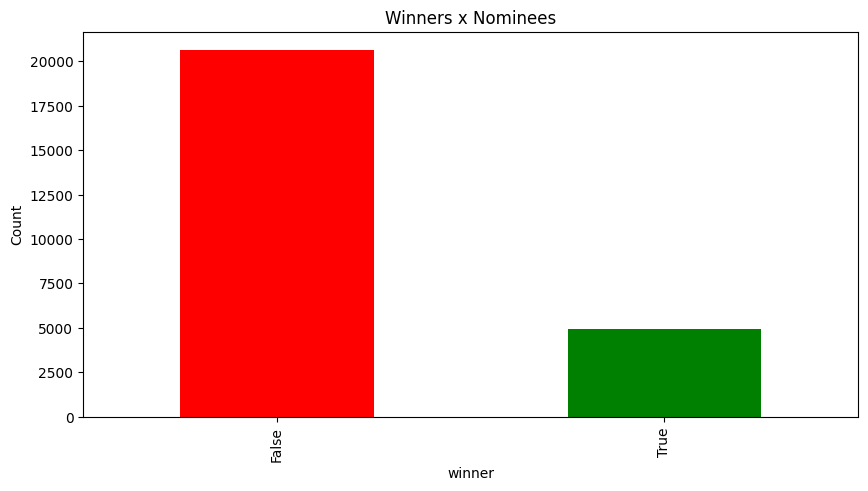

In [214]:
plt.figure(figsize=(10, 5))

plt.title('Winners x Nominees')

plt.ylabel('Count')
plt.xlabel('Result')

plt.grid(axis='y', linestyle='--', alpha=0.7)

winners_x_nominees = df.groupby('winner')['winner'].count()
winners_x_nominees.plot(kind='bar', color=['red', 'green'])

plt.show()

## Number of entries per year

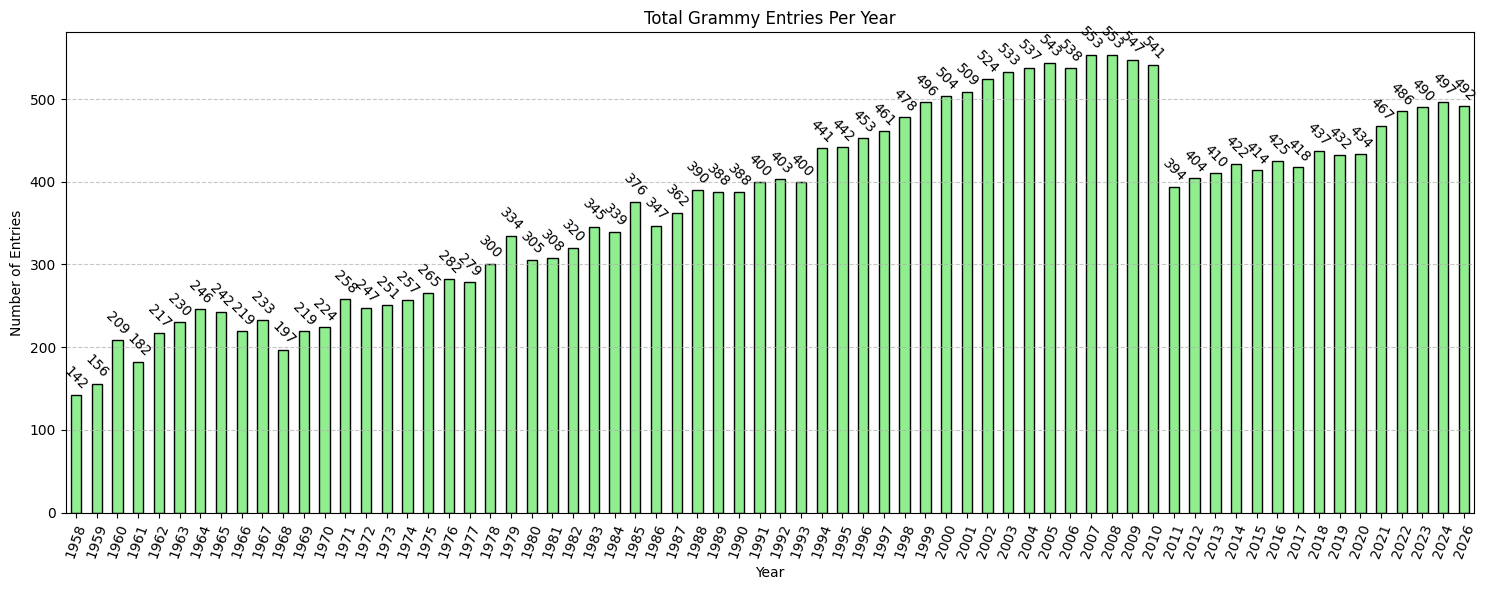

In [215]:
plt.figure(figsize=(15, 6))

ax = grouping.plot(kind='bar', color='lightgreen', edgecolor='black')

plt.title('Total Grammy Entries Per Year')


plt.xlabel('Year')
plt.ylabel('Number of Entries')
plt.xticks(rotation=70)
plt.grid(axis='y', linestyle='--', alpha=0.7)

params = {'ha': 'center', 'va': 'center', 'rotation': -45}

for p in ax.patches:
    height = p.get_height()
    x = p.get_x() + p.get_width() / 2
    y = height + 20
    ax.text(x, y, f'{int(height)}', **params)

plt.tight_layout()
plt.show()

In [216]:
category_df = df[['year', 'annual_edition', 'award']].drop_duplicates(['award'])
category_by_year = category_df.groupby('year')['award'].count()

In [217]:
category_df.head(n=5)

,year,annual_edition,award
20695,1958,1,Album Of The Year
20767,1958,1,Best Album Cover
20753,1958,1,Best Arrangement
20816,1958,1,Best Classical Performance - Chamber Music (In...
20811,1958,1,Best Classical Performance - Instrumentalist (...


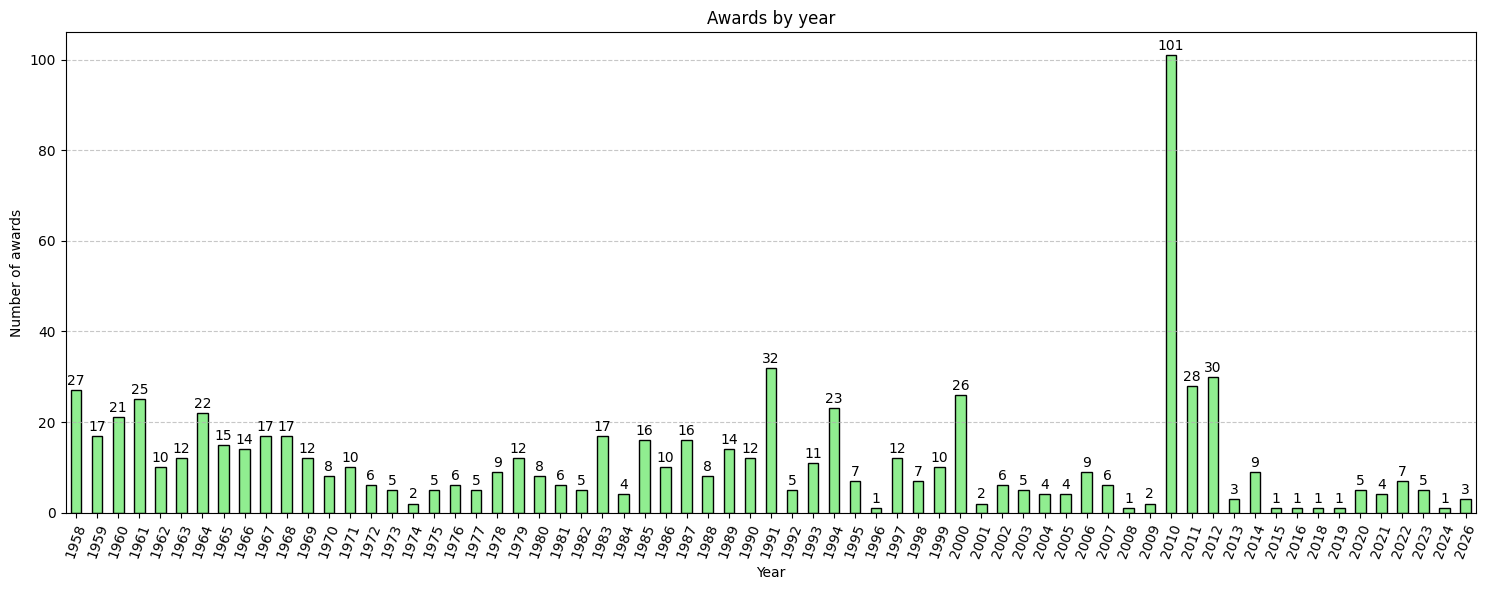

In [218]:
plt.figure(figsize=(15, 6))

ax = category_by_year.plot(kind='bar', color='lightgreen', edgecolor='black')

plt.title('Awards by year')

plt.xlabel('Year')
plt.ylabel('Number of awards')

plt.xticks(rotation=70)
plt.grid(axis='y', linestyle='--', alpha=0.7)

params = {'ha': 'center', 'va': 'center'}

for p in ax.patches:
    height = p.get_height()
    x = p.get_x() + p.get_width() / 2
    y = height + 2
    ax.text(x, y, f'{int(height)}', **params)

plt.tight_layout()
plt.show()

In [219]:
winners = df[df.winner == True]
winners_by_year = winners.groupby('year')['artist'].count()

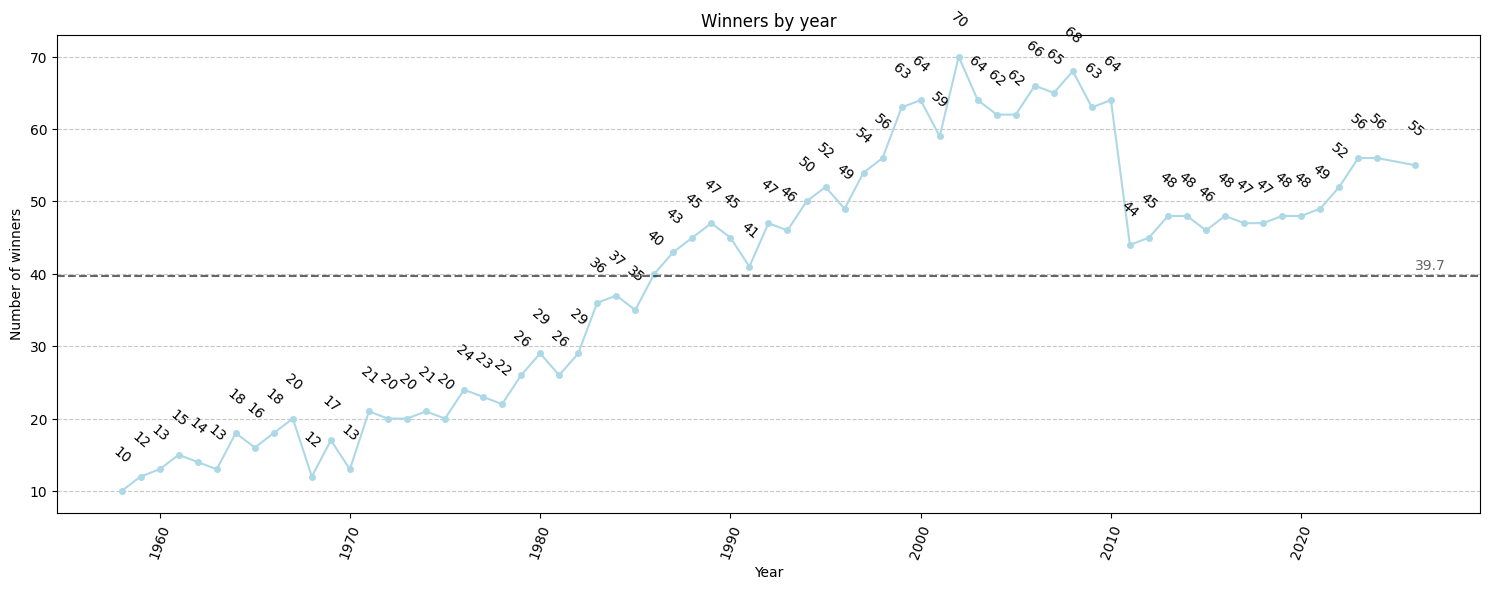

In [220]:
plt.figure(figsize=(15, 6))

ax = winners_by_year.plot(kind='line', color='lightblue', marker='o', markersize=4)

plt.title('Winners by year')

plt.xlabel('Year')
plt.ylabel('Number of winners')

plt.xticks(rotation=70)
plt.grid(axis='y', linestyle='--', alpha=0.7)

params = {'ha': 'center', 'va': 'center', 'rotation': -40}

for x, y in zip(winners_by_year.index, winners_by_year.values):
    ax.text(x, y + 5, f'{int(y)}', **params)


# Calculate average
avg_winners = winners_by_year.mean()
ax.axhline(y=avg_winners, color='black', linestyle='--', alpha=0.6, linewidth=1.5, label='Average')

x_pos = winners_by_year.index[-1]
ax.text(x_pos, avg_winners + 0.5, f'{avg_winners:.1f}', color='black', alpha=0.6, fontsize=10, ha='left', va='bottom')

plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()

plt.show()

In [221]:
df.to_csv('grammies_v4.csv', index=False)

## Add categories

Add categories to the dataset. The main ones are `is_album`, `is_song`, `is_new_artist` and `is_single`

In [222]:
awards_df = df[['award']].drop_duplicates()

In [223]:
def is_album(inner_df: pandas.DataFrame) -> pandas.DataFrame:
    inner_df['is_album'] = inner_df['award'].str.contains('Album', case=False, na=False)
    return inner_df

In [224]:
def is_song(inner_df: pandas.DataFrame) -> pandas.DataFrame:
    inner_df['is_song'] = inner_df['award'].str.contains('Song', case=False, na=False)
    return inner_df

In [225]:
def is_new_artist(inner_df: pandas.DataFrame) -> pandas.DataFrame:
    inner_df['is_artist'] = inner_df['award'].str.contains('New Artist', case=False, na=False) | inner_df['award'].str.contains('Artist', case=False, na=False)
    return inner_df

In [226]:
def is_single(inner_df: pandas.DataFrame) -> pandas.DataFrame:
    inner_df['is_single'] = any([
        inner_df['award'].str.contains('Single Record', case=False, na=False),
        inner_df['award'].str.contains('Country & Western Single', case=False, na=False),
        inner_df['award'].str.contains('(R&R) Single', case=False, na=False),
        inner_df['award'].str.contains('Contemporary Single', case=False, na=False),
    ])
    return inner_df

In [227]:
awards_df.pipe(is_album).pipe(is_song).pipe(is_new_artist)

,award,is_album,is_song,is_artist
20695,Album Of The Year,True,False,False
20767,Best Album Cover,True,False,False
20753,Best Arrangement,False,False,False
20816,Best Classical Performance - Chamber Music (In...,False,False,False
20811,Best Classical Performance - Instrumentalist (...,False,False,False
...,...,...,...,...
9283,Best Pop Dance Recording,False,False,False
23483,Best Dance Pop Recording,False,False,False
224,Best Contemporary Country Album,True,False,False
219,Best Traditional Country Album,True,False,False


## Artists

In [228]:
artists_df = df[['artist', 'artist_link']].drop_duplicates()

In [229]:
artists_df.sort_values(by=['artist'], inplace=True)

In [230]:
artists_df.to_csv('artists.csv', index=False)

In [231]:
awards_df.to_csv('categories.csv', index=False)